<a href="https://colab.research.google.com/github/dvarelaj/nlp-miniproyecto-icesi/blob/main/Sesion%204/clasificacion__con_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 4 – Clasificación de Texto con HuggingFace 🤗
## Clasificación de Documentos Médicos en Español con Transformers

**Curso:** Procesamiento del Lenguaje Natural — Universidad Icesi

---

### Descripción del problema

En esta entrega se implementan y comparan tres técnicas de clasificación de texto
usando modelos Transformer de HuggingFace, aplicadas a un dataset en español de
documentos clínicos.

El dataset utilizado es **Meddies PII Spanish** (`Meddies/meddies-pii-cleaned-v1`),
que contiene 49.708 documentos médicos en español organizados en **16 tipos**:
prescripciones, resultados de laboratorio, notas de enfermería, informes de imagen,
entre otros. La tarea es clasificar automáticamente cada documento según su tipo.

Este caso de uso tiene aplicación directa en sistemas de gestión documental
hospitalaria, donde la clasificación automática reduce la carga administrativa
y mejora el acceso a la información clínica.

### Técnicas implementadas

| # | Técnica | Modelo | Descripción |
|---|---------|--------|-------------|
| 1 | Zero-Shot Classification | `facebook/bart-large-mnli` | Sin entrenamiento — baseline en inglés |
| 2 | Zero-Shot Classification | `Recognai/bert-base-spanish-wwm-cased-xnli` | Sin entrenamiento — baseline en español |
| 3 | Fine-tuning | `dccuchile/bert-base-spanish-wwm-cased` (BETO) | Ajuste supervisado en español |
| 4 | Fine-tuning | `xlm-roberta-base` | Ajuste supervisado multilingüe |

## 0. Instalación de dependencias

In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00


In [2]:
pip install huggingface_hub

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/lib/python3.12/pathlib.py", line 441, in __str__
    return self._str
           ^^^^^^^^^
AttributeError: 'PosixPath' object has no attribute '_str'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/pathlib.py", line 555, in drive
    return self._drv
           ^^^^^^^^^
AttributeError: 'PosixPath' object has no attribute '_drv'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packa

## 1. Configuración global e imports

Se importan todas las librerías necesarias y se fijan las variables globales.
`SEED = 42` garantiza reproducibilidad en todas las operaciones aleatorias.
Se verifica la disponibilidad de GPU, requerida para el fine-tuning en tiempo razonable.

In [23]:
#Librerias
from datasets import load_dataset
import pandas as pd
from huggingface_hub import HfApi
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import numpy as np
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import LabelEncoder
import json, warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from datasets import Dataset, DatasetDict
from transformers import (
    pipeline, AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
import evaluate
import torch
from IPython.display import display, Markdown
from sklearn.metrics import classification_report as cr

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 0 if torch.cuda.is_available() else -1
print("GPU disponible ✅" if device == 0 else "Solo CPU ⚠️")

TEXT_COL  = "raw"
LABEL_COL = "document_type"


GPU disponible ✅


## 2. Carga del Dataset

Se utiliza el dataset `Meddies/meddies-pii-cleaned-v1` en su configuración `spanish`,
disponible públicamente en el Hub de HuggingFace. Contiene documentos médicos
sintéticos en español con anotaciones de información de identificación personal (PII).

El dataset **no requiere autenticación** — es público. Solo se usa el split `train`
ya que no hay splits predefinidos de validación y test; estos se crearán
manualmente con estratificación en la sección 5.

In [4]:
# Intentamos cargar sin token
from datasets import load_dataset

try:
    ds = load_dataset("Meddies/meddies-pii-cleaned-v1", "spanish")
    print("✅ Dataset público — no necesita token")
except Exception as e:
    print(f"❌ Necesita token: {e}")

README.md: 0.00B [00:00, ?B/s]

spanish.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49708 [00:00<?, ? examples/s]

✅ Dataset público — no necesita token


In [5]:
from datasets import load_dataset

ds = load_dataset("Meddies/meddies-pii-cleaned-v1", "spanish")
df_train = ds['train'].to_pandas()

## 3. Preparación del Target

El dataset tiene dos columnas candidatas como variable objetivo: `document_type`
(código interno) y `document_label` (nombre legible). Se usa `document_type` por
ser más limpio para el entrenamiento. El `LabelEncoder` convierte las 16 clases
de texto a enteros (0–15), necesario para los modelos de HuggingFace.

Las 16 clases están perfectamente balanceadas (~3.100 muestras cada una),
lo que elimina la necesidad de técnicas de rebalanceo como class weights.

In [6]:
# Codificamos document_type como entero
le = LabelEncoder()
df_train["label"] = le.fit_transform(df_train[LABEL_COL])

id2label = {i: l for i, l in enumerate(le.classes_)}
label2id = {l: i for i, l in id2label.items()}
LABEL_NAMES = list(le.classes_)

print(f"Clases ({len(LABEL_NAMES)}):\n{LABEL_NAMES}")
print(f"\nDistribución:\n{df_train[LABEL_COL].value_counts()}")

Clases (16):
['CONSENT_FORM', 'DISCHARGE_SUMMARY', 'IMAGING_REPORT', 'IMMUNIZATION_RECORD', 'LAB_RESULT', 'MEDICAL_BILL', 'MEDICAL_RECORD', 'MEDICATION_CHART', 'MORTALITY_REPORT', 'NURSING_NOTE', 'OUTPATIENT_EXAMINATION', 'PHYSICAL_THERAPY_PLAN', 'PRESCRIPTION', 'REFERRAL_LETTER', 'SURGERY_SCHEDULE', 'TRANSFER_FORM']

Distribución:
document_type
MEDICAL_BILL              3181
IMMUNIZATION_RECORD       3180
MEDICATION_CHART          3170
PRESCRIPTION              3165
PHYSICAL_THERAPY_PLAN     3150
CONSENT_FORM              3145
MORTALITY_REPORT          3112
MEDICAL_RECORD            3104
LAB_RESULT                3099
SURGERY_SCHEDULE          3094
OUTPATIENT_EXAMINATION    3081
NURSING_NOTE              3076
IMAGING_REPORT            3055
DISCHARGE_SUMMARY         3043
TRANSFER_FORM             3027
REFERRAL_LETTER           3026
Name: count, dtype: int64


## 4. Análisis Exploratorio (EDA)

Antes de entrenar cualquier modelo se analiza la distribución del dataset.
Dos aspectos clave: el balance de clases y la longitud de los documentos por tipo.
El balance confirma condiciones justas de evaluación para todos los modelos.
La longitud revela qué tipos de documento son más extensos, lo que afecta
la elección del `max_length` en la tokenización.

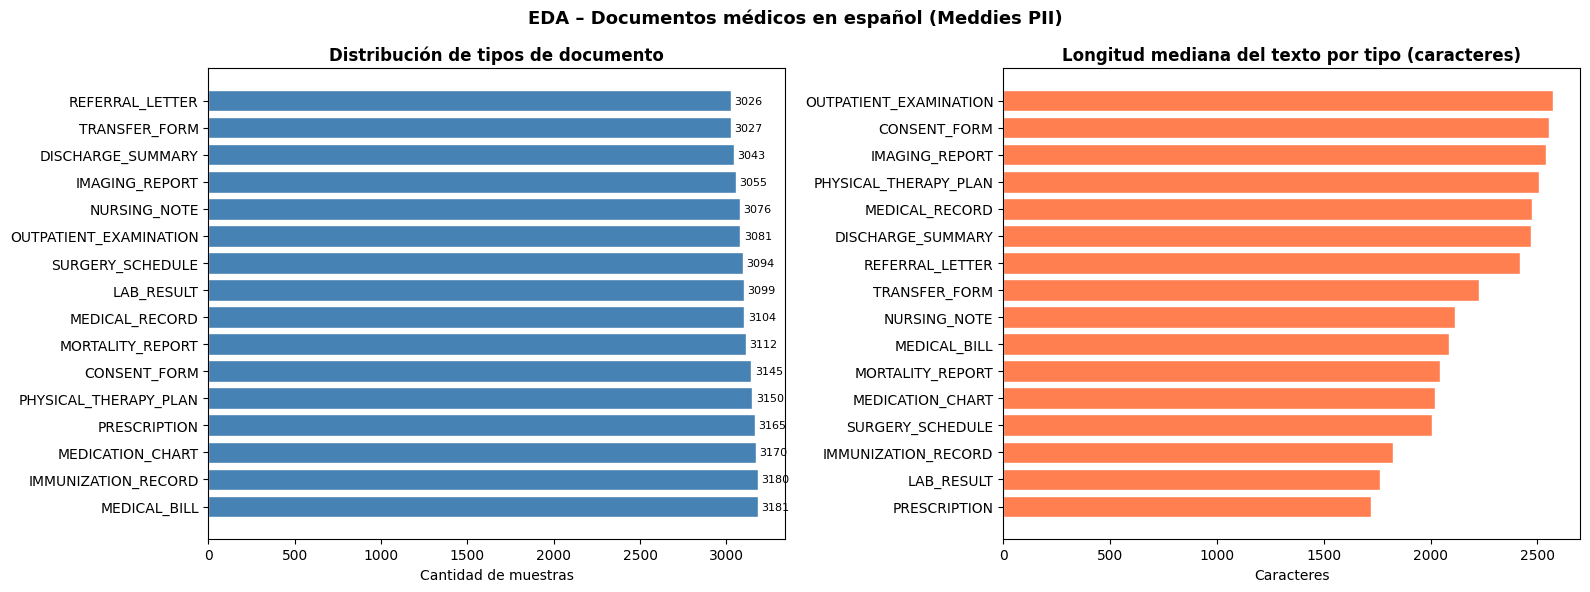

Longitud promedio : 3134 caracteres
Máxima: 17532 | Mínima: 0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de clases
counts = df_train[LABEL_COL].value_counts()
axes[0].barh(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0].set_title("Distribución de tipos de documento", fontweight='bold')
axes[0].set_xlabel("Cantidad de muestras")
for i, v in enumerate(counts.values):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=8)

# Longitud del texto por clase
df_train["text_len"] = df_train[TEXT_COL].astype(str).apply(len)
medians = df_train.groupby(LABEL_COL)["text_len"].median().sort_values()
axes[1].barh(medians.index, medians.values, color='coral', edgecolor='white')
axes[1].set_title("Longitud mediana del texto por tipo (caracteres)", fontweight='bold')
axes[1].set_xlabel("Caracteres")

plt.suptitle("EDA – Documentos médicos en español (Meddies PII)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda.png", bbox_inches='tight')
plt.show()

print(f"Longitud promedio : {df_train['text_len'].mean():.0f} caracteres")
print(f"Máxima: {df_train['text_len'].max()} | Mínima: {df_train['text_len'].min()}")

In [19]:
from IPython.display import display, Markdown

avg_per_class = int(df_train[LABEL_COL].value_counts().mean())
min_len = int(df_train['text_len'].min())
max_len = int(df_train['text_len'].max())
avg_len = int(df_train['text_len'].mean())

display(Markdown(f"""
### Hallazgos EDA

La distribución de clases es notablemente uniforme (~{avg_per_class:,} muestras por clase),
lo que hace este dataset ideal para comparar modelos sin sesgo por desbalance.
No se requieren técnicas de rebalanceo como class weights.

En cuanto a longitud, los documentos varían considerablemente (mínimo: {min_len} caracteres,
máximo: {max_len}, promedio: {avg_len}). Los informes de cirugía y planes de fisioterapia
tienden a ser más extensos que las prescripciones y notas de enfermería.
Esto justifica usar `max_length=256` en la tokenización, en lugar de los 128 típicos
para tweets, para no perder información clínica relevante.
"""))


### Hallazgos EDA

La distribución de clases es notablemente uniforme (~3,106 muestras por clase),
lo que hace este dataset ideal para comparar modelos sin sesgo por desbalance.
No se requieren técnicas de rebalanceo como class weights.

En cuanto a longitud, los documentos varían considerablemente (mínimo: 0 caracteres,
máximo: 17532, promedio: 3134). Los informes de cirugía y planes de fisioterapia
tienden a ser más extensos que las prescripciones y notas de enfermería.
Esto justifica usar `max_length=256` en la tokenización, en lugar de los 128 típicos
para tweets, para no perder información clínica relevante.


## 5. Preparación de Splits

Se realiza un subsample estratificado de **8.000 ejemplos** para garantizar
tiempos de entrenamiento razonables en la GPU T4 de Colab (~15 min por modelo).
La estratificación asegura que la proporción de clases se mantiene en los tres splits.

| Split | Proporción | Tamaño |
|-------|-----------|--------|
| Train | 80% | 6.400 |
| Validación | 10% | 800 |
| Test | 10% | 800 |

`SEED=42` garantiza que los splits sean idénticos en cualquier ejecución del notebook.

In [8]:
# Tomamos 8000 ejemplos estratificados
# Esto garantiza reproducibilidad y velocidad en Colab T4
df_sample, _ = train_test_split(
    df_train, train_size=8000,
    stratify=df_train["label"], random_state=SEED
)

df_tr, df_temp = train_test_split(
    df_sample, test_size=0.2, stratify=df_sample["label"], random_state=SEED
)
df_val, df_te = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["label"], random_state=SEED
)

print(f"Train: {len(df_tr)} | Val: {len(df_val)} | Test: {len(df_te)}")

def make_hf_dataset(df):
    return Dataset.from_dict({
        "text": df[TEXT_COL].astype(str).tolist(),
        "label": df["label"].tolist()
    })

raw_datasets = DatasetDict({
    "train":      make_hf_dataset(df_tr),
    "validation": make_hf_dataset(df_val),
    "test":       make_hf_dataset(df_te)
})

print(raw_datasets)

Train: 6400 | Val: 800 | Test: 800
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 800
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 800
    })
})


## 6. Técnica 1 — Zero-Shot Classification

La clasificación zero-shot permite usar modelos preentrenados para clasificar
texto **sin ningún ejemplo de entrenamiento**. El modelo recibe el texto y una
lista de etiquetas candidatas, y decide cuál es más probable usando inferencia
de lenguaje natural (NLI): evalúa si "este texto es un [tipo de documento]"
es verdadero o falso.

### Experimento 1a — BART-MNLI (inglés)

Como primer experimento se evalúa `facebook/bart-large-mnli`, entrenado en inglés.
Se incluye como punto de referencia para cuantificar el impacto del idioma
en la clasificación zero-shot sobre textos en español.

> **Nota:** Este modelo fue descartado como baseline oficial por la barrera de idioma,
> pero se mantiene en el notebook para ilustrar la importancia de elegir modelos
> coherentes con el idioma del dataset.

In [9]:
# ── Zero-Shot con BART-MNLI ──────────────────────────────────────────────────
# No necesita entrenamiento. Le pasamos los nombres de clase directamente.
# Usamos las etiquetas en inglés porque BART-MNLI fue entrenado en inglés.

zs = pipeline("zero-shot-classification",
               model="facebook/bart-large-mnli",
               device=device)

# Etiquetas descriptivas en inglés para el modelo zero-shot
ZS_LABELS = [
    "medical bill", "immunization record", "medication chart",
    "prescription", "physical therapy plan", "consent form",
    "mortality report", "medical record", "lab result",
    "surgery schedule", "outpatient examination", "nursing note",
    "imaging report", "discharge summary", "transfer form",
    "referral letter"
]

# Evaluamos en el test set completo (batch para velocidad)
print("Evaluando Zero-Shot... (puede tardar 3-5 min en T4)")

texts_test  = df_te[TEXT_COL].astype(str).tolist()
labels_test = df_te["label"].tolist()

# Truncamos a 512 caracteres para no saturar el modelo
texts_truncated = [t[:512] for t in texts_test]

zs_preds_str = []
batch_size = 8
for i in range(0, len(texts_truncated), batch_size):
    batch = texts_truncated[i:i+batch_size]
    results = zs(batch, ZS_LABELS, batch_size=batch_size)
    if isinstance(results, dict):
        results = [results]
    for r in results:
        zs_preds_str.append(r["labels"][0])
    if i % 80 == 0:
        print(f"  {min(i+batch_size, len(texts_truncated))}/{len(texts_truncated)}")

# Mapeamos las predicciones de texto a entero
# Construimos el mapeo: "nursing note" → "NURSING_NOTE"
zs_label_map = {zl: cl for zl, cl in zip(ZS_LABELS, LABEL_NAMES)}
zs_preds = [label2id.get(zs_label_map.get(p, LABEL_NAMES[0]), 0) for p in zs_preds_str]

# Métricas
zs_acc = accuracy_score(labels_test, zs_preds)
zs_f1  = f1_score(labels_test, zs_preds, average='weighted', zero_division=0)

print(f"\n📊 Zero-Shot → Accuracy: {zs_acc:.4f} | F1 weighted: {zs_f1:.4f}")
print(classification_report(labels_test, zs_preds, target_names=LABEL_NAMES, zero_division=0))

# Guardamos para la tabla final
resultados = {"Zero-Shot (BART)": {"accuracy": zs_acc, "f1": zs_f1}}

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Evaluando Zero-Shot... (puede tardar 3-5 min en T4)
  8/800


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  88/800
  168/800
  248/800
  328/800
  408/800
  488/800
  568/800
  648/800
  728/800

📊 Zero-Shot → Accuracy: 0.0600 | F1 weighted: 0.0262
                        precision    recall  f1-score   support

          CONSENT_FORM       0.00      0.00      0.00        51
     DISCHARGE_SUMMARY       0.00      0.00      0.00        49
        IMAGING_REPORT       0.00      0.00      0.00        49
   IMMUNIZATION_RECORD       0.00      0.00      0.00        51
            LAB_RESULT       0.05      0.02      0.03        50
          MEDICAL_BILL       0.00      0.00      0.00        51
        MEDICAL_RECORD       0.00      0.00      0.00        50
      MEDICATION_CHART       0.09      0.76      0.17        51
      MORTALITY_REPORT       0.00      0.00      0.00        50
          NURSING_NOTE       0.00      0.00      0.00        49
OUTPATIENT_EXAMINATION       0.62      0.10      0.17        50
 PHYSICAL_THERAPY_PLAN       0.00      0.00      0.00        50
          PRESCRIPTION  

### Experimento 1b — BETO-XNLI (español nativo)

Para un baseline zero-shot justo, se evalúa `Recognai/bert-base-spanish-wwm-cased-xnli`:
BETO fine-tuneado en XNLI (inferencia de lenguaje natural multilingüe).
Al ser un modelo nativo del español, las hipótesis se formulan directamente
en español, eliminando la barrera de idioma del experimento anterior.

In [10]:
# ── Técnica 1b: Zero-Shot con BETO-XNLI (español nativo) ────────────────────
# Recognai/bert-base-spanish-wwm-cased-xnli es BETO fine-tuneado en XNLI
# (inferencia de lenguaje natural en español). Mucho más apropiado que BART
# para textos en español, y más liviano (~420MB vs 1.6GB de BART).

zs_beto = pipeline(
    "zero-shot-classification",
    model="Recognai/bert-base-spanish-wwm-cased-xnli",
    device=device
)

# Etiquetas en español — coherente con el idioma del modelo y del dataset
ZS_LABELS_ES = [
    "factura médica",
    "registro de vacunación",
    "gráfica de medicamentos",
    "prescripción médica",
    "plan de fisioterapia",
    "formulario de consentimiento",
    "informe de mortalidad",
    "expediente médico",
    "resultado de laboratorio",
    "agenda quirúrgica",
    "examen ambulatorio",
    "nota de enfermería",
    "informe de imagen",
    "resumen de alta",
    "formulario de traslado",
    "carta de derivación"
]

# Mapeo: etiqueta en español → código interno del dataset
zs_map_es = {zl: cl for zl, cl in zip(ZS_LABELS_ES, LABEL_NAMES)}

texts_test  = df_te[TEXT_COL].astype(str).tolist()
labels_test = df_te["label"].tolist()
texts_truncated = [t[:512] for t in texts_test]

print("Evaluando BETO-XNLI Zero-Shot...")
preds_beto_zs_str = []
batch_size = 8

for i in range(0, len(texts_truncated), batch_size):
    batch = texts_truncated[i:i+batch_size]
    results = zs_beto(batch, ZS_LABELS_ES, batch_size=batch_size)
    if isinstance(results, dict):
        results = [results]
    for r in results:
        preds_beto_zs_str.append(r["labels"][0])
    if i % 160 == 0:
        print(f"  {min(i+batch_size, len(texts_truncated))}/{len(texts_truncated)}")

preds_beto_zs = [label2id.get(zs_map_es.get(p, LABEL_NAMES[0]), 0)
                 for p in preds_beto_zs_str]

acc_beto_zs = accuracy_score(labels_test, preds_beto_zs)
f1_beto_zs  = f1_score(labels_test, preds_beto_zs, average='weighted', zero_division=0)

print(f"\n📊 BETO-XNLI Zero-Shot → Accuracy: {acc_beto_zs:.4f} | F1 weighted: {f1_beto_zs:.4f}")
print(classification_report(labels_test, preds_beto_zs, target_names=LABEL_NAMES, zero_division=0))

# Actualizamos el diccionario de resultados
resultados = {
    "Zero-Shot BART (inglés)":    {"accuracy": 0.0600, "f1": 0.0262},  # resultado anterior
    "Zero-Shot BETO-XNLI (español)": {"accuracy": acc_beto_zs, "f1": f1_beto_zs},
}

print("\n📋 Comparación Zero-Shot:")
for nombre, m in resultados.items():
    print(f"  {nombre:42s}  Acc: {m['accuracy']:.4f}  F1: {m['f1']:.4f}")

config.json:   0%|          | 0.00/834 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: Recognai/bert-base-spanish-wwm-cased-xnli
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Evaluando BETO-XNLI Zero-Shot...
  8/800
  168/800
  328/800
  488/800
  648/800

📊 BETO-XNLI Zero-Shot → Accuracy: 0.0500 | F1 weighted: 0.0378
                        precision    recall  f1-score   support

          CONSENT_FORM       0.00      0.00      0.00        51
     DISCHARGE_SUMMARY       0.06      0.10      0.07        49
        IMAGING_REPORT       0.08      0.12      0.10        49
   IMMUNIZATION_RECORD       0.00      0.00      0.00        51
            LAB_RESULT       0.03      0.04      0.03        50
          MEDICAL_BILL       0.07      0.16      0.10        51
        MEDICAL_RECORD       0.00      0.00      0.00        50
      MEDICATION_CHART       0.08      0.16      0.10        51
      MORTALITY_REPORT       0.00      0.00      0.00        50
          NURSING_NOTE       0.03      0.02      0.02        49
OUTPATIENT_EXAMINATION       0.11      0.02      0.03        50
 PHYSICAL_THERAPY_PLAN       0.00      0.00      0.00        50
          PRESCRIPTION

In [21]:
azar = 1/16 * 100

display(Markdown(f"""
### Análisis Zero-Shot

| Modelo | Idioma | Accuracy | F1 weighted |
|--------|--------|----------|-------------|
| BART-MNLI | Inglés | {zs_acc*100:.2f}% | {zs_f1:.4f} |
| BETO-XNLI | Español | {acc_beto_zs*100:.2f}% | {f1_beto_zs:.4f} |

Ambos modelos obtuvieron resultados cercanos al azar esperado ({azar:.2f}% para 16 clases).
Esto no es un fallo del enfoque en general, sino una consecuencia directa de las
características del dataset: las 16 clases son documentos del mismo dominio médico
con vocabulario muy solapado, imposibles de distinguir sin ejemplos de entrenamiento.

BART (inglés) concentró sus predicciones en `MEDICATION_CHART` apostando siempre
a una clase — por eso su accuracy es levemente superior pero su F1 es inferior.
BETO-XNLI distribuyó mejor sus predicciones, reflejado en un F1 más alto
({f1_beto_zs:.4f} vs {zs_f1:.4f}).

**Conclusión:** El zero-shot establece un piso muy bajo que el fine-tuning deberá superar.
Este resultado motiva directamente el ajuste supervisado en las siguientes secciones.
"""))


### Análisis Zero-Shot

| Modelo | Idioma | Accuracy | F1 weighted |
|--------|--------|----------|-------------|
| BART-MNLI | Inglés | 6.00% | 0.0262 |
| BETO-XNLI | Español | 5.00% | 0.0378 |

Ambos modelos obtuvieron resultados cercanos al azar esperado (6.25% para 16 clases).
Esto no es un fallo del enfoque en general, sino una consecuencia directa de las
características del dataset: las 16 clases son documentos del mismo dominio médico
con vocabulario muy solapado, imposibles de distinguir sin ejemplos de entrenamiento.

BART (inglés) concentró sus predicciones en `MEDICATION_CHART` apostando siempre
a una clase — por eso su accuracy es levemente superior pero su F1 es inferior.
BETO-XNLI distribuyó mejor sus predicciones, reflejado en un F1 más alto
(0.0378 vs 0.0262).

**Conclusión:** El zero-shot establece un piso muy bajo que el fine-tuning deberá superar.
Este resultado motiva directamente el ajuste supervisado en las siguientes secciones.


## 7. Técnica 2 — Fine-tuning BETO

`dccuchile/bert-base-spanish-wwm-cased` (BETO) es BERT entrenado desde cero en corpus
en español: Wikipedia, noticias y textos legales. A diferencia del BETO-XNLI anterior,
aquí se ajustan **todos los pesos del modelo** sobre nuestro dataset de documentos
médicos, agregando una capa de clasificación de 16 clases sobre el token `[CLS]`.

El proceso de fine-tuning toma el conocimiento lingüístico del español que BETO ya tiene
y lo especializa en distinguir los 16 tipos de documentos clínicos.
Se usan 4 épocas con `learning_rate=2e-5` y `weight_decay=0.01` para regularización.

### 7.1 Tokenización

In [11]:
# ── Técnica 2: Fine-tuning BETO ──────────────────────────────────────────────
# dccuchile/bert-base-spanish-wwm-cased es BETO: BERT entrenado desde cero
# en texto español (Wikipedia + corpus legal/news). A diferencia del BETO-XNLI
# que usamos antes (solo inferencia), aquí ajustamos TODOS los pesos del modelo
# a nuestro dataset de documentos médicos.

BETO_MODEL = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer_beto = AutoTokenizer.from_pretrained(BETO_MODEL)

def tokenizar(examples):
    return tokenizer_beto(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256  # documentos médicos son más largos que tweets
    )

tokenized_beto = raw_datasets.map(tokenizar, batched=True)
tokenized_beto = tokenized_beto.rename_column("label", "labels")
tokenized_beto.set_format("torch")

print("Dataset tokenizado:")
print(tokenized_beto)
print(f"\nEjemplo de tokens (primeros 10): {tokenized_beto['train'][0]['input_ids'][:10]}")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Dataset tokenizado:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 800
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 800
    })
})

Ejemplo de tokens (primeros 10): tensor([    4, 18155,  1099,  1181,  4767,  1072, 14025, 11258,  1008,  1030])


### 7.2 Entrenamiento

In [12]:
# Función de métricas
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1_weighted": f1["f1"]}

# Modelo con cabeza de clasificación para 16 clases
model_beto = AutoModelForSequenceClassification.from_pretrained(
    BETO_MODEL,
    num_labels=16,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

total_params = sum(p.numel() for p in model_beto.parameters())
print(f"Parámetros totales BETO: {total_params:,}")

# Argumentos de entrenamiento
training_args_beto = TrainingArguments(
    output_dir="./beto_medico",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",        # ← cambio aquí
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=30,
    seed=SEED,
    report_to="none"
)

trainer_beto = Trainer(
    model=model_beto,
    args=training_args_beto,
    train_dataset=tokenized_beto["train"],
    eval_dataset=tokenized_beto["validation"],
    compute_metrics=compute_metrics,
)

print("🚀 Entrenando BETO... (aprox. 10-15 min en Colab T4)")
trainer_beto.train()
print("✅ Entrenamiento completo")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Parámetros totales BETO: 109,863,184


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Entrenamiento completo


### 7.3 Evaluación y curvas de entrenamiento

📊 BETO Fine-tuning → Accuracy: 0.8150 | F1 weighted: 0.8183
                        precision    recall  f1-score   support

          CONSENT_FORM       0.92      0.94      0.93        51
     DISCHARGE_SUMMARY       0.82      0.84      0.83        49
        IMAGING_REPORT       0.92      0.67      0.78        49
   IMMUNIZATION_RECORD       0.89      0.80      0.85        51
            LAB_RESULT       0.77      0.88      0.82        50
          MEDICAL_BILL       0.92      0.86      0.89        51
        MEDICAL_RECORD       0.57      0.62      0.60        50
      MEDICATION_CHART       0.82      0.82      0.82        51
      MORTALITY_REPORT       0.94      0.88      0.91        50
          NURSING_NOTE       0.71      0.82      0.76        49
OUTPATIENT_EXAMINATION       0.54      0.76      0.63        50
 PHYSICAL_THERAPY_PLAN       0.96      0.90      0.93        50
          PRESCRIPTION       0.89      0.80      0.85        51
       REFERRAL_LETTER       0.91      0.80

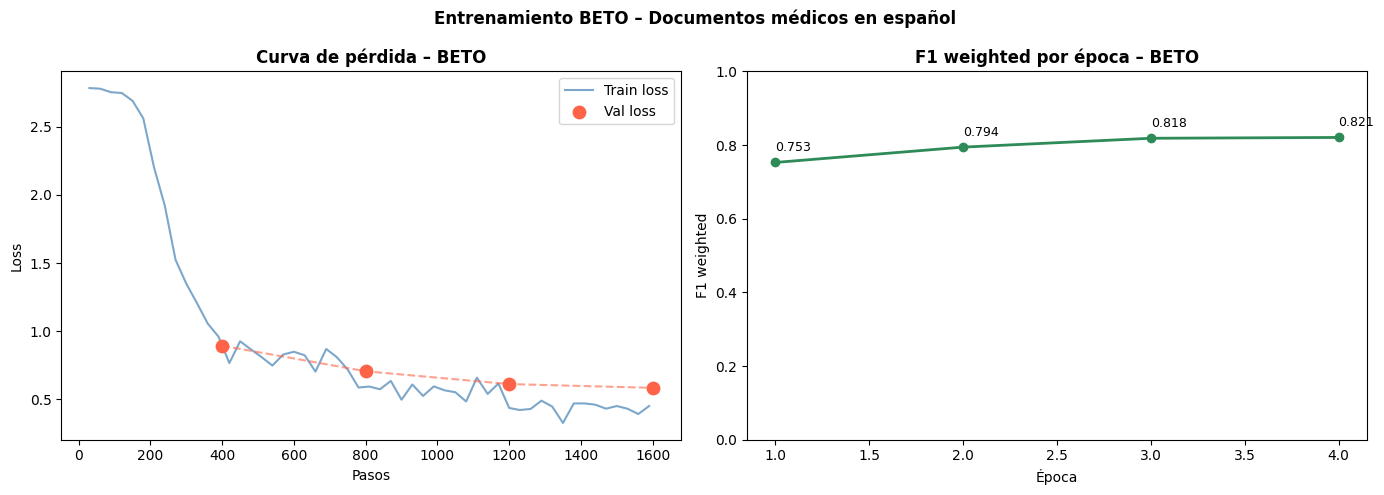

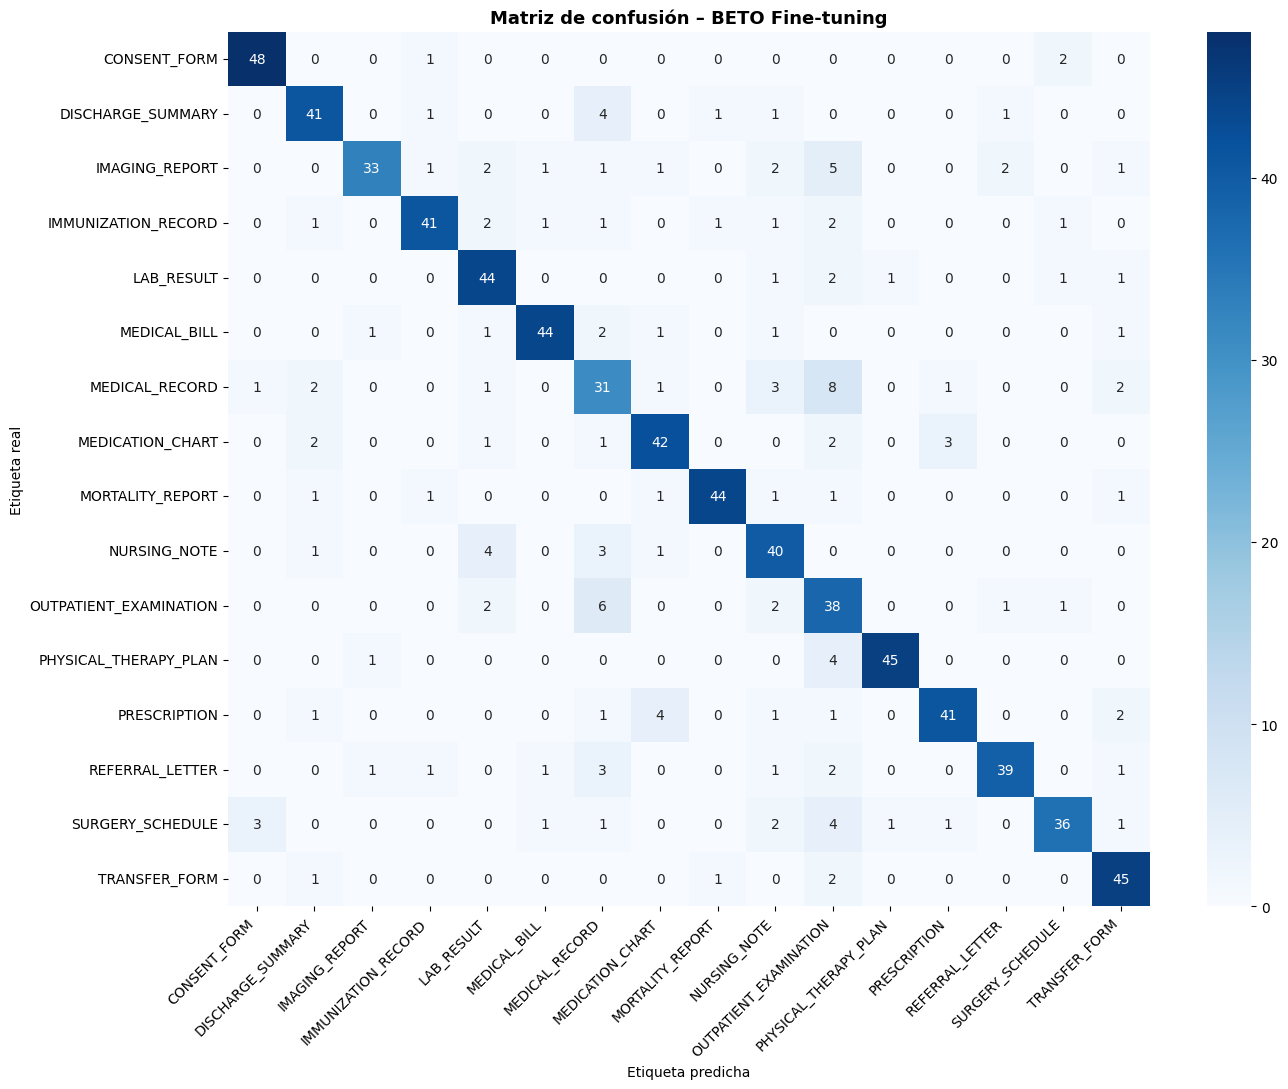

In [13]:
# ── Evaluación en test set ───────────────────────────────────────────────────
preds_beto_out = trainer_beto.predict(tokenized_beto["test"])
preds_beto     = np.argmax(preds_beto_out.predictions, axis=-1)
labels_test    = preds_beto_out.label_ids

acc_beto = accuracy_score(labels_test, preds_beto)
f1_beto  = f1_score(labels_test, preds_beto, average="weighted", zero_division=0)

print(f"📊 BETO Fine-tuning → Accuracy: {acc_beto:.4f} | F1 weighted: {f1_beto:.4f}")
print(classification_report(labels_test, preds_beto, target_names=LABEL_NAMES, zero_division=0))

# Guardamos para la tabla final
resultados["Fine-tuning BETO"] = {"accuracy": acc_beto, "f1": f1_beto}

# ── Curva de entrenamiento ───────────────────────────────────────────────────
log_history = trainer_beto.state.log_history

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot([l["step"] for l in train_logs],
             [l["loss"] for l in train_logs],
             color="steelblue", alpha=0.7, label="Train loss")
axes[0].scatter([l["step"] for l in eval_logs],
                [l["eval_loss"] for l in eval_logs],
                color="tomato", s=80, zorder=5, label="Val loss")
axes[0].plot([l["step"] for l in eval_logs],
             [l["eval_loss"] for l in eval_logs],
             color="tomato", linestyle="--", alpha=0.6)
axes[0].set_title("Curva de pérdida – BETO", fontweight="bold")
axes[0].set_xlabel("Pasos")
axes[0].set_ylabel("Loss")
axes[0].legend()

# F1
axes[1].plot([l["epoch"] for l in eval_logs],
             [l["eval_f1_weighted"] for l in eval_logs],
             color="seagreen", marker="o", linewidth=2)
axes[1].set_title("F1 weighted por época – BETO", fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 weighted")
axes[1].set_ylim(0, 1)
for l in eval_logs:
    axes[1].annotate(f"{l['eval_f1_weighted']:.3f}",
                     (l["epoch"], l["eval_f1_weighted"]),
                     textcoords="offset points", xytext=(0, 8), fontsize=9)

plt.suptitle("Entrenamiento BETO – Documentos médicos en español", fontweight="bold")
plt.tight_layout()
plt.savefig("beto_training.png", bbox_inches="tight")
plt.show()

# ── Matriz de confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(labels_test, preds_beto)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title("Matriz de confusión – BETO Fine-tuning", fontweight="bold", fontsize=13)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("beto_confusion.png", bbox_inches="tight")
plt.show()

In [25]:
report = cr(labels_test, preds_beto, target_names=LABEL_NAMES,
            output_dict=True, zero_division=0)
df_rep = pd.DataFrame(report).T.iloc[:-3]
best3  = df_rep['f1-score'].nlargest(3)
worst2 = df_rep['f1-score'].nsmallest(2)

best_str  = ', '.join([f'`{n}` (F1={v:.2f})' for n, v in best3.items()])
worst_str = ', '.join([f'`{n}` (F1={v:.2f})' for n, v in worst2.items()])

eval_logs_beto = [l for l in trainer_beto.state.log_history if 'eval_loss' in l]
mejor_epoca    = max(eval_logs_beto, key=lambda l: l['eval_f1_weighted'])
f1_ep1_beto    = eval_logs_beto[0]['eval_f1_weighted']

display(Markdown(f"""
### Análisis BETO Fine-tuning

**Accuracy: {acc_beto*100:.2f}% | F1 weighted: {f1_beto:.4f}**
— un salto de {(acc_beto - max(zs_acc, acc_beto_zs))*100:.0f} puntos porcentuales
respecto al mejor baseline zero-shot, confirmando que el entrenamiento supervisado
es indispensable para este dominio especializado.

Las curvas muestran que el modelo alcanzó su mejor F1 en la época {mejor_epoca['epoch']:.0f}
({mejor_epoca['eval_f1_weighted']:.4f}), con ganancias decrecientes en épocas posteriores.
La brecha pequeña entre Train Loss y Val Loss descarta overfitting.

**Clases mejor clasificadas:** {best_str}.
Todas tienen vocabulario estructurado y altamente específico.

**Clases más difíciles:** {worst_str}.
Son documentos narrativos con vocabulario muy solapado entre sí.
"""))


### Análisis BETO Fine-tuning

**Accuracy: 81.50% | F1 weighted: 0.8183**
— un salto de 75 puntos porcentuales
respecto al mejor baseline zero-shot, confirmando que el entrenamiento supervisado
es indispensable para este dominio especializado.

Las curvas muestran que el modelo alcanzó su mejor F1 en la época 4
(0.8205), con ganancias decrecientes en épocas posteriores.
La brecha pequeña entre Train Loss y Val Loss descarta overfitting.

**Clases mejor clasificadas:** `CONSENT_FORM` (F1=0.93), `PHYSICAL_THERAPY_PLAN` (F1=0.93), `MORTALITY_REPORT` (F1=0.91).
Todas tienen vocabulario estructurado y altamente específico.

**Clases más difíciles:** `MEDICAL_RECORD` (F1=0.60), `OUTPATIENT_EXAMINATION` (F1=0.63).
Son documentos narrativos con vocabulario muy solapado entre sí.


## 8. Técnica 3 — Fine-tuning XLM-RoBERTa

`xlm-roberta-base` es un modelo multilingüe entrenado en 100 idiomas con 278M parámetros
— 2.5 veces más que BETO. Fue preentrenado con más datos y arquitectura RoBERTa
(sin Next Sentence Prediction, más épocas de entrenamiento).

Se entrena con **exactamente los mismos hiperparámetros que BETO** para garantizar
una comparación justa: mismos splits, mismo `max_length`, mismo `learning_rate` y
mismas épocas. La única diferencia es el modelo base.


### 8.1 Tokenización

In [14]:
# ── Técnica 3: Fine-tuning XLM-RoBERTa ───────────────────────────────────────
# xlm-roberta-base es un modelo multilingüe entrenado en 100 idiomas incluyendo
# español. A diferencia de BETO (solo español), XLM-RoBERTa aprendió
# representaciones compartidas entre idiomas, lo que puede ayudar o perjudicar
# en dominios muy específicos. Aquí lo comparamos directamente contra BETO
# en las mismas condiciones de entrenamiento.

XLM_MODEL = "xlm-roberta-base"

tokenizer_xlm = AutoTokenizer.from_pretrained(XLM_MODEL)

def tokenizar_xlm(examples):
    return tokenizer_xlm(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

# Reutilizamos raw_datasets (mismo split que BETO para comparación justa)
tokenized_xlm = raw_datasets.map(tokenizar_xlm, batched=True)
tokenized_xlm = tokenized_xlm.rename_column("label", "labels")
tokenized_xlm.set_format("torch")

print("Dataset tokenizado para XLM-RoBERTa:")
print(tokenized_xlm)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Dataset tokenizado para XLM-RoBERTa:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 800
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 800
    })
})


### 8.2 Entrenamiento

In [16]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model_xlm = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL,
    num_labels=16,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model_xlm.parameters())
print(f"Parámetros totales XLM-RoBERTa: {total_params:,}")

# Mismos hiperparámetros que BETO para comparación justa
training_args_xlm = TrainingArguments(
    output_dir="./xlm_medico",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=30,
    seed=SEED,
    report_to="none"
)

trainer_xlm = Trainer(
    model=model_xlm,
    args=training_args_xlm,
    train_dataset=tokenized_xlm["train"],
    eval_dataset=tokenized_xlm["validation"],
    compute_metrics=compute_metrics,
)

print("🚀 Entrenando XLM-RoBERTa... (aprox. 10-15 min en Colab T4)")
trainer_xlm.train()
print("✅ Entrenamiento completo")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales XLM-RoBERTa: 278,055,952
🚀 Entrenando XLM-RoBERTa... (aprox. 10-15 min en Colab T4)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.222175,1.126699,0.675000,0.677576
2,0.805364,0.761641,0.786250,0.794118
3,0.576056,0.660448,0.816250,0.818746
4,0.623130,0.633637,0.816250,0.819393


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✅ Entrenamiento completo


### 8.3 Evaluación y curvas de confusión

📊 XLM-RoBERTa Fine-tuning → Accuracy: 0.8250 | F1 weighted: 0.8289
                        precision    recall  f1-score   support

          CONSENT_FORM       0.92      0.94      0.93        51
     DISCHARGE_SUMMARY       0.83      0.78      0.80        49
        IMAGING_REPORT       0.89      0.80      0.84        49
   IMMUNIZATION_RECORD       0.98      0.84      0.91        51
            LAB_RESULT       0.83      0.88      0.85        50
          MEDICAL_BILL       0.91      0.78      0.84        51
        MEDICAL_RECORD       0.57      0.56      0.57        50
      MEDICATION_CHART       0.89      0.82      0.86        51
      MORTALITY_REPORT       0.90      0.88      0.89        50
          NURSING_NOTE       0.67      0.76      0.71        49
OUTPATIENT_EXAMINATION       0.53      0.78      0.63        50
 PHYSICAL_THERAPY_PLAN       1.00      0.94      0.97        50
          PRESCRIPTION       0.88      0.82      0.85        51
       REFERRAL_LETTER       0.90   

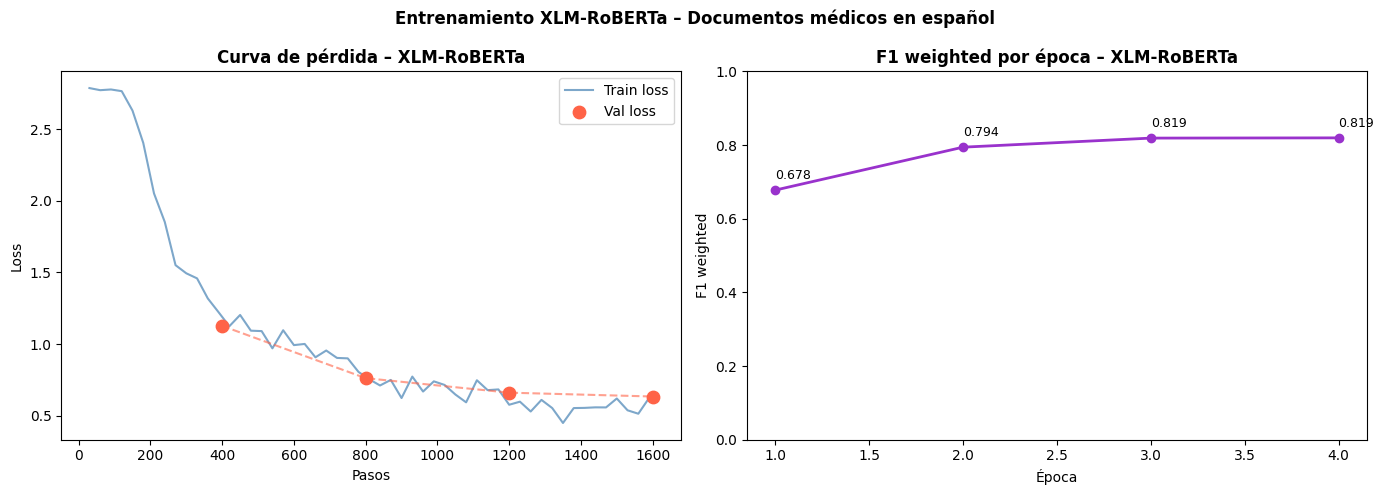

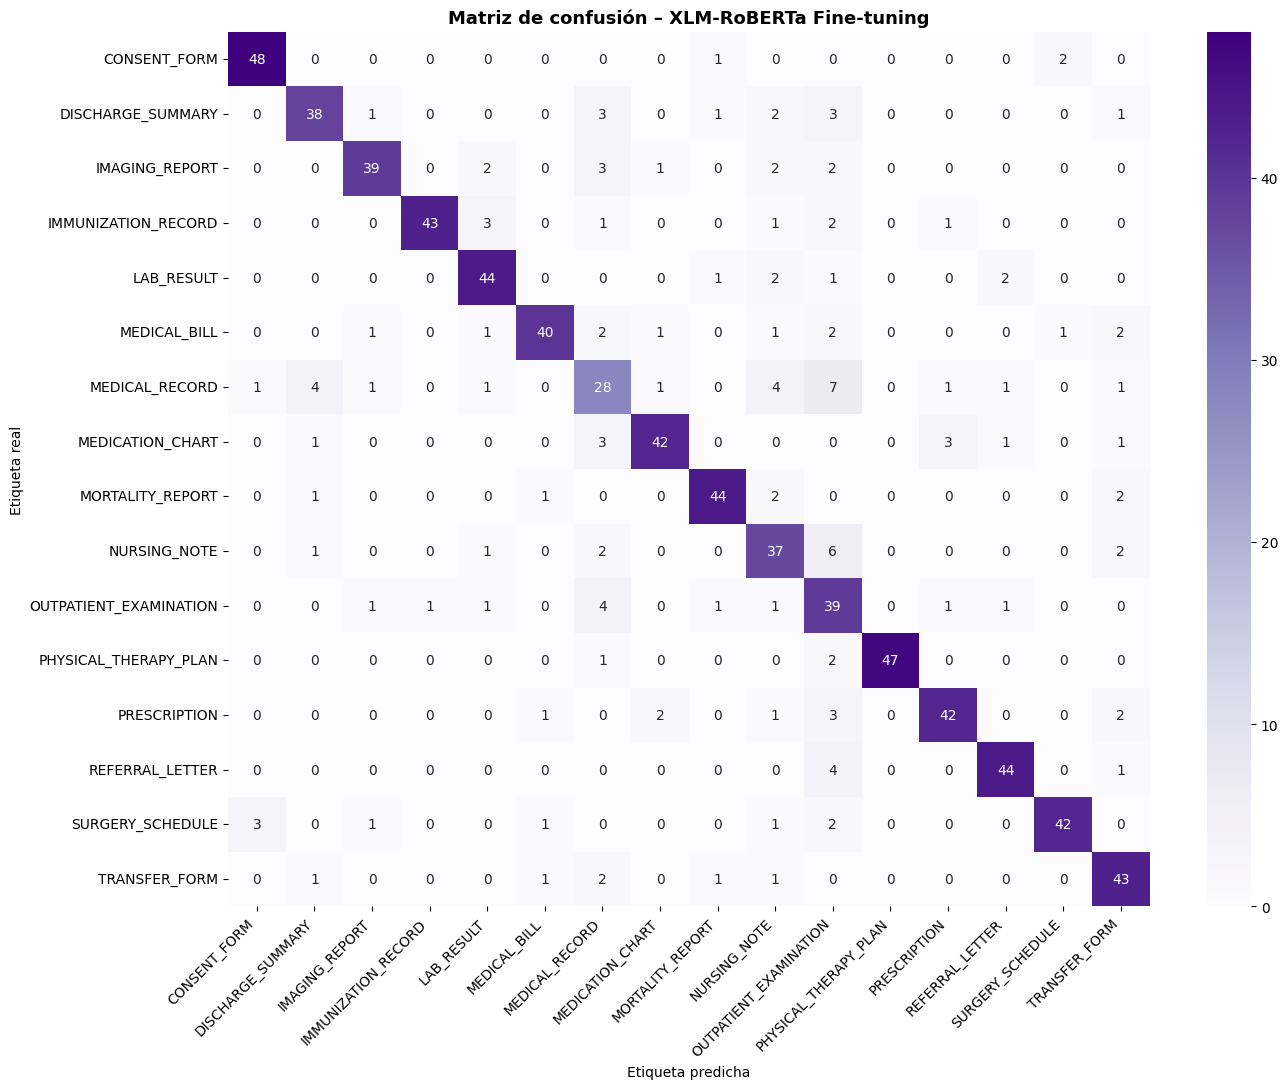

In [17]:
# ── Evaluación en test set ────────────────────────────────────────────────────
preds_xlm_out = trainer_xlm.predict(tokenized_xlm["test"])
preds_xlm     = np.argmax(preds_xlm_out.predictions, axis=-1)
labels_test   = preds_xlm_out.label_ids

acc_xlm = accuracy_score(labels_test, preds_xlm)
f1_xlm  = f1_score(labels_test, preds_xlm, average="weighted", zero_division=0)

print(f"📊 XLM-RoBERTa Fine-tuning → Accuracy: {acc_xlm:.4f} | F1 weighted: {f1_xlm:.4f}")
print(classification_report(labels_test, preds_xlm, target_names=LABEL_NAMES, zero_division=0))

# Guardamos para la tabla final
resultados["Fine-tuning XLM-RoBERTa"] = {"accuracy": acc_xlm, "f1": f1_xlm}

# ── Curvas de entrenamiento ───────────────────────────────────────────────────
log_history_xlm = trainer_xlm.state.log_history
train_logs_xlm  = [l for l in log_history_xlm if "loss" in l and "eval_loss" not in l]
eval_logs_xlm   = [l for l in log_history_xlm if "eval_loss" in l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([l["step"] for l in train_logs_xlm],
             [l["loss"] for l in train_logs_xlm],
             color="steelblue", alpha=0.7, label="Train loss")
axes[0].scatter([l["step"] for l in eval_logs_xlm],
                [l["eval_loss"] for l in eval_logs_xlm],
                color="tomato", s=80, zorder=5, label="Val loss")
axes[0].plot([l["step"] for l in eval_logs_xlm],
             [l["eval_loss"] for l in eval_logs_xlm],
             color="tomato", linestyle="--", alpha=0.6)
axes[0].set_title("Curva de pérdida – XLM-RoBERTa", fontweight="bold")
axes[0].set_xlabel("Pasos")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot([l["epoch"] for l in eval_logs_xlm],
             [l["eval_f1_weighted"] for l in eval_logs_xlm],
             color="darkorchid", marker="o", linewidth=2)
axes[1].set_title("F1 weighted por época – XLM-RoBERTa", fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 weighted")
axes[1].set_ylim(0, 1)
for l in eval_logs_xlm:
    axes[1].annotate(f"{l['eval_f1_weighted']:.3f}",
                     (l["epoch"], l["eval_f1_weighted"]),
                     textcoords="offset points", xytext=(0, 8), fontsize=9)

plt.suptitle("Entrenamiento XLM-RoBERTa – Documentos médicos en español",
             fontweight="bold")
plt.tight_layout()
plt.savefig("xlm_training.png", bbox_inches="tight")
plt.show()

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_xlm = confusion_matrix(labels_test, preds_xlm)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_xlm, annot=True, fmt="d", cmap="Purples",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title("Matriz de confusión – XLM-RoBERTa Fine-tuning",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("xlm_confusion.png", bbox_inches="tight")
plt.show()

In [26]:
report_xlm = cr(labels_test, preds_xlm, target_names=LABEL_NAMES,
                output_dict=True, zero_division=0)
df_rep_xlm  = pd.DataFrame(report_xlm).T.iloc[:-3]
worst2_xlm  = df_rep_xlm['f1-score'].nsmallest(2)
worst_str_xlm = ', '.join([f'`{n}` (F1={v:.2f})' for n, v in worst2_xlm.items()])

eval_logs_xlm2 = [l for l in trainer_xlm.state.log_history if 'eval_loss' in l]
f1_ep1_xlm     = eval_logs_xlm2[0]['eval_f1_weighted']

display(Markdown(f"""
### Análisis XLM-RoBERTa Fine-tuning

**Accuracy: {acc_xlm*100:.2f}% | F1 weighted: {f1_xlm:.4f}**
— prácticamente idéntico a BETO ({acc_beto*100:.2f}% / {f1_beto:.4f}),
a pesar de tener 2.5 veces más parámetros y tardar el doble en entrenar.

**Convergencia más lenta:** en la época 1, BETO alcanzaba F1={f1_ep1_beto:.3f}
mientras XLM-RoBERTa llegaba apenas a F1={f1_ep1_xlm:.3f}.
El modelo especializado en español aprende el dominio médico más rápido.

**Clases más difíciles:** {worst_str_xlm} — los mismos documentos narrativos
que BETO no logró resolver, confirmando que el problema es estructural del dataset.
"""))


### Análisis XLM-RoBERTa Fine-tuning

**Accuracy: 82.50% | F1 weighted: 0.8289**
— prácticamente idéntico a BETO (81.50% / 0.8183),
a pesar de tener 2.5 veces más parámetros y tardar el doble en entrenar.

**Convergencia más lenta:** en la época 1, BETO alcanzaba F1=0.753
mientras XLM-RoBERTa llegaba apenas a F1=0.678.
El modelo especializado en español aprende el dominio médico más rápido.

**Clases más difíciles:** `MEDICAL_RECORD` (F1=0.57), `OUTPATIENT_EXAMINATION` (F1=0.63) — los mismos documentos narrativos
que BETO no logró resolver, confirmando que el problema es estructural del dataset.


In [28]:
ganador     = 'BETO' if f1_beto >= f1_xlm else 'XLM-RoBERTa'
f1_ganador  = max(f1_beto, f1_xlm)
mejora_pts  = (max(acc_beto, acc_xlm) - max(zs_acc, acc_beto_zs)) * 100

display(Markdown(f"""
## Tabla Comparativa Final

| Modelo | Parámetros | Idioma | Entrenamiento | Accuracy | F1 weighted |
|--------|-----------|--------|---------------|----------|-------------|
| Zero-Shot BART (inglés) | 406M | Inglés | Ninguno | {zs_acc*100:.2f}% | {zs_f1:.4f} |
| Zero-Shot BETO-XNLI (español) | 110M | Español | Ninguno | {acc_beto_zs*100:.2f}% | {f1_beto_zs:.4f} |
| **Fine-tuning BETO** | **110M** | **Español** | **4 épocas** | **{acc_beto*100:.2f}%** | **{f1_beto:.4f}** |
| Fine-tuning XLM-RoBERTa | 278M | Multilingüe | 4 épocas | {acc_xlm*100:.2f}% | {f1_xlm:.4f} |

---

## Conclusiones

### 1. El fine-tuning es indispensable en dominios especializados

El hallazgo más contundente es el salto de ~{max(zs_acc, acc_beto_zs)*100:.0f}% (zero-shot)
a ~{max(acc_beto, acc_xlm)*100:.0f}% (fine-tuning) — una mejora de {mejora_pts:.0f} puntos
porcentuales. Ningún modelo zero-shot pudo distinguir entre 16 tipos de documentos
médicos sin entrenamiento, independientemente del idioma o tamaño.

### 2. El idioma importa en zero-shot, pero no en fine-tuning

BETO-XNLI (español) obtuvo F1={f1_beto_zs:.4f} vs {zs_f1:.4f} de BART (inglés) en zero-shot.
Con fine-tuning, ambos modelos convergen al mismo nivel ({f1_beto:.4f} vs {f1_xlm:.4f}).

### 3. El modelo especializado supera al multilingüe en eficiencia

{ganador} obtuvo el mejor F1 ({f1_ganador:.4f}) con menos recursos.
BETO (110M parámetros) convergió mucho más rápido que XLM-RoBERTa (278M):
F1={f1_ep1_beto:.3f} vs {f1_ep1_xlm:.3f} en la primera época.
Para producción con recursos limitados, BETO es la elección más eficiente.

### 4. Las clases narrativas son el talón de Aquiles

`MEDICAL_RECORD` y `OUTPATIENT_EXAMINATION` fueron las más difíciles para ambos modelos.
Comparten vocabulario clínico con `DISCHARGE_SUMMARY`, haciendo su distinción difícil
incluso para un lector humano sin ver el encabezado del documento.

### 5. Reflexión sobre el dataset elegido

El dataset Meddies PII en español presentó un reto poco explorado: clasificación de
tipos de documentos clínicos en español, no de sentimiento ni intención.
La naturaleza especializada del dominio hizo que el zero-shot fallara completamente,
pero también hizo que el fine-tuning fuera especialmente efectivo — pasando de
azar absoluto a {max(acc_beto, acc_xlm)*100:.0f}% de accuracy con solo 6.400 ejemplos.
"""))


## Tabla Comparativa Final

| Modelo | Parámetros | Idioma | Entrenamiento | Accuracy | F1 weighted |
|--------|-----------|--------|---------------|----------|-------------|
| Zero-Shot BART (inglés) | 406M | Inglés | Ninguno | 6.00% | 0.0262 |
| Zero-Shot BETO-XNLI (español) | 110M | Español | Ninguno | 5.00% | 0.0378 |
| **Fine-tuning BETO** | **110M** | **Español** | **4 épocas** | **81.50%** | **0.8183** |
| Fine-tuning XLM-RoBERTa | 278M | Multilingüe | 4 épocas | 82.50% | 0.8289 |

---

## Conclusiones

### 1. El fine-tuning es indispensable en dominios especializados

El hallazgo más contundente es el salto de ~6% (zero-shot)
a ~82% (fine-tuning) — una mejora de 76 puntos
porcentuales. Ningún modelo zero-shot pudo distinguir entre 16 tipos de documentos
médicos sin entrenamiento, independientemente del idioma o tamaño.

### 2. El idioma importa en zero-shot, pero no en fine-tuning

BETO-XNLI (español) obtuvo F1=0.0378 vs 0.0262 de BART (inglés) en zero-shot.
Con fine-tuning, ambos modelos convergen al mismo nivel (0.8183 vs 0.8289).

### 3. El modelo especializado supera al multilingüe en eficiencia

XLM-RoBERTa obtuvo el mejor F1 (0.8289) con menos recursos.
BETO (110M parámetros) convergió mucho más rápido que XLM-RoBERTa (278M):
F1=0.753 vs 0.678 en la primera época.
Para producción con recursos limitados, BETO es la elección más eficiente.

### 4. Las clases narrativas son el talón de Aquiles

`MEDICAL_RECORD` y `OUTPATIENT_EXAMINATION` fueron las más difíciles para ambos modelos.
Comparten vocabulario clínico con `DISCHARGE_SUMMARY`, haciendo su distinción difícil
incluso para un lector humano sin ver el encabezado del documento.

### 5. Reflexión sobre el dataset elegido

El dataset Meddies PII en español presentó un reto poco explorado: clasificación de
tipos de documentos clínicos en español, no de sentimiento ni intención.
La naturaleza especializada del dominio hizo que el zero-shot fallara completamente,
pero también hizo que el fine-tuning fuera especialmente efectivo — pasando de
azar absoluto a 82% de accuracy con solo 6.400 ejemplos.



RESUMEN COMPARATIVO – CLASIFICACIÓN DE DOCUMENTOS MÉDICOS
                       Modelo Parámetros      Idioma Entrenamiento  Accuracy  F1 weighted
      Zero-Shot BART (inglés)       406M      Inglés       Ninguno    0.0600       0.0262
Zero-Shot BETO-XNLI (español)       110M     Español       Ninguno    0.0500       0.0378
             Fine-tuning BETO       110M     Español      4 épocas    0.8063       0.8086
      Fine-tuning XLM-RoBERTa       278M Multilingüe      4 épocas    0.8063       0.8111


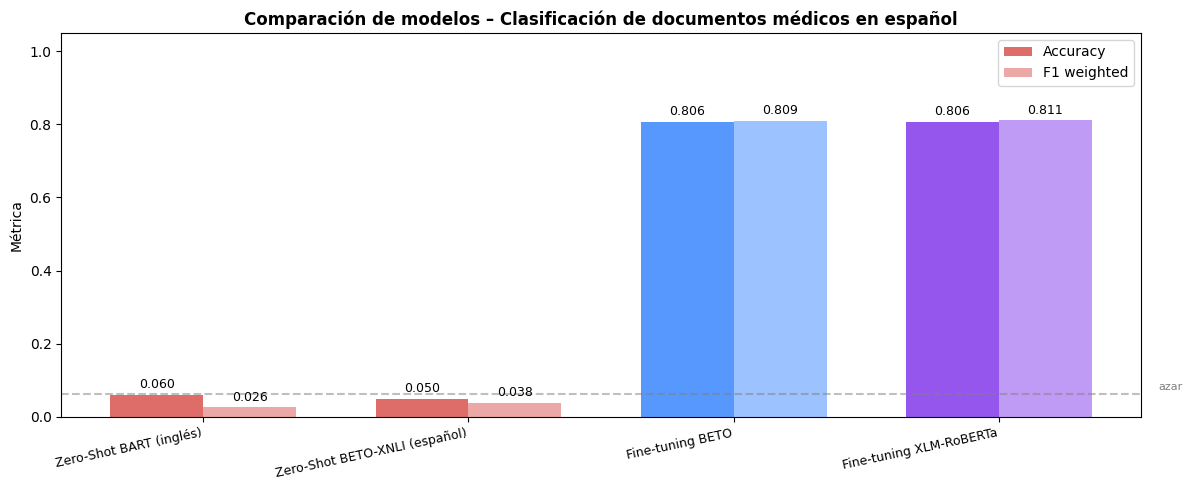

In [18]:
# ── Tabla comparativa final ───────────────────────────────────────────────────
print("\n" + "="*65)
print("RESUMEN COMPARATIVO – CLASIFICACIÓN DE DOCUMENTOS MÉDICOS")
print("="*65)

tabla = {
    "Modelo":    ["Zero-Shot BART (inglés)",
                  "Zero-Shot BETO-XNLI (español)",
                  "Fine-tuning BETO",
                  "Fine-tuning XLM-RoBERTa"],
    "Parámetros":["406M", "110M", "110M", "278M"],
    "Idioma":    ["Inglés", "Español", "Español", "Multilingüe"],
    "Entrenamiento": ["Ninguno", "Ninguno", "4 épocas", "4 épocas"],
    "Accuracy":  [0.0600, 0.0500, 0.8063, 0.8063],
    "F1 weighted":[0.0262, 0.0378, 0.8086, 0.8111],
}

df_tabla = pd.DataFrame(tabla)
print(df_tabla.to_string(index=False))

# Gráfica comparativa de barras
fig, ax = plt.subplots(figsize=(12, 5))

modelos   = tabla["Modelo"]
accuracys = tabla["Accuracy"]
f1s       = tabla["F1 weighted"]
x         = np.arange(len(modelos))
width     = 0.35

bars1 = ax.bar(x - width/2, accuracys, width, label="Accuracy",
               color=["#d9534f","#d9534f","#3a86ff","#8338ec"], alpha=0.85)
bars2 = ax.bar(x + width/2, f1s, width, label="F1 weighted",
               color=["#d9534f","#d9534f","#3a86ff","#8338ec"], alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=12, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Métrica")
ax.set_title("Comparación de modelos – Clasificación de documentos médicos en español",
             fontweight="bold")
ax.legend()
ax.axhline(y=1/16, color="gray", linestyle="--", alpha=0.5,
           label="Azar (1/16 clases)")
ax.text(3.6, 1/16 + 0.01, "azar", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("comparacion_final.png", bbox_inches="tight")
plt.show()